In [420]:
from py_files.setup import *
setup_notebook()

# %pip install git+https://github.com/alemartinello/dstapi
from IPython.display import display
from io import StringIO
from dstapi import DstApi
from functools import reduce

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. `Industry use decomposition`

In [421]:
# 0. datasets
NAIO1F = DstApi('NAIO1F')
NAN1 = DstApi('NAN1')

# NAIO1F.tablesummary(language='en')
# NAIO1F.variable_levels('TILGANG1',language='en')
# df = NAIO1F.variable_levels('ANVENDELSE',language='en')
# df.loc[df["id"].eq("ABI"), "text"].iloc[0]

# mask = df["text"].astype("string").str.contains("SA", case=False, na=False)
# df[mask]

*`1.1. make tangible intangible split`*

In [422]:
out_fetch = [
    'ACPT',     # Household consumption total
    'ACO',      # Government consumption total
    'ABI',      # Gross fixed capital formation total
    'AE6000',   # Exports   
    'AI00000',  # intgermidiate consumption (for organisational services)
]

# 1. fetch
params_intan = {
    'table' : 'NAIO1F',
    'format': 'BULK',
    'lang'  : 'en',
    'variables': [
        {'code': 'PRISENHED'    , 'values': ['V']},       
        {'code': 'Tid'          , 'values': ['*']},
        {'code': 'TILGANG1'     , 'values': ['P1_BP']},   
        {'code': 'TILGANG2'     , 'values': ['*']},     
        {'code': 'ANVENDELSE'   , 'values': out_fetch}, 
    ]
}

intan_ = NAIO1F.get_data(params=params_intan)
intan_['INDHOLD'] = pd.to_numeric(intan_['INDHOLD'], errors='coerce')

# 2. data manipulatui
intan = intan_[['TID','TILGANG2','ANVENDELSE','INDHOLD']].copy()

In [423]:
# 1. fetch
params_io = {
    'table' : 'NAIO1F',
    'format': 'BULK',
    'lang'  : 'en',
    'variables': [
        {'code': 'PRISENHED'    , 'values': ['V']},       
        {'code': 'Tid'          , 'values': ['*']},
        {'code': 'TILGANG1'     , 'values': ['P7AD2121']},   
        {'code': 'TILGANG2'     , 'values': ['*']},      
        {'code': 'ANVENDELSE'   , 'values': ['AIAE']}, 
    ]
}

io_im = NAIO1F.get_data(params=params_io)
io_im['INDHOLD'] = pd.to_numeric(io_im['INDHOLD'], errors='coerce')
io_im = io_im.rename(columns={'INDHOLD' : 'M'})

*map to tangibility and main category*

In [424]:
# extract the code (first 5 characters, or up to the first space)
intan['code'] = intan['TILGANG2'].str.split(' ').str[0]
io_im['code'] = io_im['TILGANG2'].str.split(' ').str[0]

# map using the extracted code
intan['type'] = intan['code'].map(var_groups.industry_classification)
intan['parent'] = intan['code'].map(var_groups.sub_to_parent)

io_im['type'] = io_im['code'].map(var_groups.industry_classification)
io_im['parent'] = io_im['code'].map(var_groups.sub_to_parent)

# keep only subcategories
intan_sub = intan.dropna(subset=['type'])
io_im_sub = io_im.dropna(subset=['type'])

*segment investment types*

In [425]:
# 1. make clean
io_T = intan_sub.pivot_table(
    index=['TID','TILGANG2','type','parent','code'], 
    columns='ANVENDELSE', 
    values='INDHOLD').reset_index()

io_T = io_T.rename(columns={
    'Exports - (Use)'                           : 'X',
    'Gross fixed capiatal formation - (Use)'    : 'GFCF',
    'Household consumption expenditures (Use)'  : 'C',
    'Total Government Consumption-(Use)'        : 'G',
    'Total Intermedialte Consumption-(Use)'     : 'GFCF_orga',
})

# 2. split tangible and intangible (from GFCF)
io_T['d_intan'] = io_T.type.eq('intangible')
io_T['d_orga']  = io_T.type.eq('organisational')

io_T['intan'] = io_T['d_intan'] * io_T['GFCF']
io_T['tan']   = (~io_T['d_intan'] & ~io_T['d_orga']).astype(int) * io_T['GFCF']

# 3. organisational: 60% of intermediate consumption → intangible investment
kappa = 0.6
io_T['orga_intan'] = io_T['d_orga'] * kappa * io_T['GFCF_orga']

# org services' own GFCF goes to intangible too
io_T['intan'] += io_T['d_orga'] * io_T['GFCF'] + io_T['orga_intan']

*merge with imports and set up final df structure*

In [426]:
# 3. add imports
io_T = io_T.merge(io_im_sub[['TID','TILGANG2','M']], on=['TID','TILGANG2'], how='left')

# 3. aggregate to parent level
io_parent = io_T.groupby(['TID','parent']).agg({
    'C': 'sum',
    'G': 'sum',
    'X': 'sum',
    'M': 'sum',
    'intan': 'sum',
    'tan': 'sum'
}).reset_index()

# 4. final use shares
IO_parent = io_parent.copy()
IO_parent['denominator'] = (
    IO_parent["C"] + IO_parent["G"] 
    + IO_parent["intan"] + IO_parent["tan"] 
    + np.abs(IO_parent["X"] - IO_parent['M'])
)

*print*

In [427]:
# 5. shares
IO_parent["C_share"] = (IO_parent["C"] + IO_parent["G"]) / IO_parent['denominator'] * 100
IO_parent["intan_share"] = IO_parent["intan"] / IO_parent['denominator'] * 100
IO_parent["tan_share"] = IO_parent["tan"] / IO_parent['denominator'] * 100
# IO_parent["X_share"] = IO_parent["X"] / IO_parent['denominator'] * 100
# IO_parent["M_share"] = IO_parent["M"] / IO_parent['denominator'] * 100
IO_parent['NX_share'] = (IO_parent["X"] - IO_parent['M']) / IO_parent['denominator'] * 100

*`1.2. get GDP to compute uses/GDP`*

In [428]:
# 1. get using DST API
NAN1 = DstApi('NAN1')
# NAHI.tablesummary(language='en')
# NAHI.variable_levels('AKTIV',language='en')

# 2. set up fetch
params_Y = {
    'table': 'NAN1',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V_M']},   # current prices (b. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'TRANSAKT', 'values': ['B1GQK']}
        ]
}

# 3. get data
df_Y = NAN1.get_data(params=params_Y)
df_Y['INDHOLD'] = pd.to_numeric(df_Y['INDHOLD'], errors='coerce')

# 4. unit and structure
GDP = (df_Y.loc[df_Y['TRANSAKT'].eq('B.1*g Gross domestic product'), ['TID','INDHOLD']]
         .groupby('TID', as_index=False)['INDHOLD'].sum()
         .rename(columns={'INDHOLD': 'GDP'}))
GDP['GDP_cp'] = GDP.GDP * 1e3

# 1. merge with GDP
IO_GDP = IO_parent.copy()
IO_GDP = IO_GDP.merge(GDP[['TID','GDP_cp']], on='TID', how='left')

# 2. compute industry share of GDP
IO_GDP['final_use'] = (IO_GDP['C'] + IO_GDP['G'] + IO_GDP['intan'] + IO_GDP['tan'] + IO_GDP['X'] - IO_GDP['M'])
IO_GDP['final_use_share'] = IO_GDP['final_use'] / IO_GDP['GDP_cp'] * 100

# 5. print all for a specific year
year = 2024
# cols = ['parent','C_share','intan_share','tan_share','X_share', 'M_share']
cols = ['parent','C_share','intan_share','tan_share','NX_share','final_use_share']

IO_parent_year = IO_GDP[IO_GDP['TID'] == year]
IO_parent_year = IO_parent_year[cols].copy()

IO_parent_year['sum_share'] = (IO_parent_year['C_share'] + IO_parent_year['intan_share'] 
                               + IO_parent_year['tan_share'] 
                            #    + IO_parent_year['X_share'] + IO_parent_year['M_share']
                               + np.abs(IO_parent_year['NX_share']  )                             
)

IO_parent_year = IO_parent_year.sort_values(by='intan_share', ascending=False)

IO_parent_year['C_share']     = IO_parent_year['C_share'].round(1)
IO_parent_year['intan_share'] = IO_parent_year['intan_share'].round(1)
IO_parent_year['tan_share']   = IO_parent_year['tan_share'].round(1)
IO_parent_year['sum_share']   = IO_parent_year['sum_share'].round(0)
IO_parent_year['NX_share']    = IO_parent_year['NX_share'].round(1)
IO_parent_year['final_use_share'] = IO_parent_year['final_use_share'].round(1)

*`1.3 replicate Figur 2 for sanity`*

*set up*

In [429]:
# 1. get slice of decomposition table
io_decomp = io_T[['TID','code','type','intan','tan']].copy()   

# 2. merge with DGP
io_decomp = io_decomp.merge(GDP[['TID','GDP_cp']], on='TID', how='left')

# 3. map to type
io_decomp['inv_type'] = io_decomp['code'].map(var_groups.investment_type)
io_sub = io_decomp.dropna(subset=['inv_type'])

# 4.a aggregate (simple)
io_sub_agg = io_sub.groupby(['TID']).agg({
    'intan': 'sum',
    'tan': 'sum',
    'GDP_cp': 'first'
}).reset_index()

io_sub_agg['intan_s'] = io_sub_agg['intan'] / io_sub_agg['GDP_cp'] * 100
io_sub_agg['tan_s'] = io_sub_agg['tan'] / io_sub_agg['GDP_cp'] * 100

# 4.b aggregate by type
io_sub['tot_inv'] = io_sub['intan'] + io_sub['tan']
io_sub_type = io_sub.groupby(['TID','inv_type']).agg({
    'tot_inv': 'sum',
    'GDP_cp': 'first'
}).reset_index()

print(f'Intantibles start at: {io_sub_agg.iloc[0].intan_s:.2f},  and tangibles at: {io_sub_agg.iloc[0].tan_s:.2f}')
print(f'Intangibles end at:   {io_sub_agg.iloc[-1].intan_s:.2f}, and tangibles at: {io_sub_agg.iloc[-1].tan_s:.2f}')

# 5. set up for plot
df = io_sub_type.copy()
df["tot_inv"] = pd.to_numeric(df["tot_inv"], errors="coerce")
df["GDP_cp"]  = pd.to_numeric(df["GDP_cp"],  errors="coerce")

# 6. share of GDP in percent
df["share_pct"] = 100 * df["tot_inv"] / df["GDP_cp"]

# 7. wide table (one row per year)
wide = (df.pivot_table(index="TID", columns="inv_type", values="share_pct", aggfunc="sum")
          .sort_index()
          .fillna(0.0))

# 8. aggregate categories
wide['intangible'] = wide['intellectual_property'] + wide['organizational']
wide['tangible'] = wide['equipment'] + wide['structures']

Intantibles start at: 3.25,  and tangibles at: 19.97
Intangibles end at:   10.14, and tangibles at: 12.20


*plot*

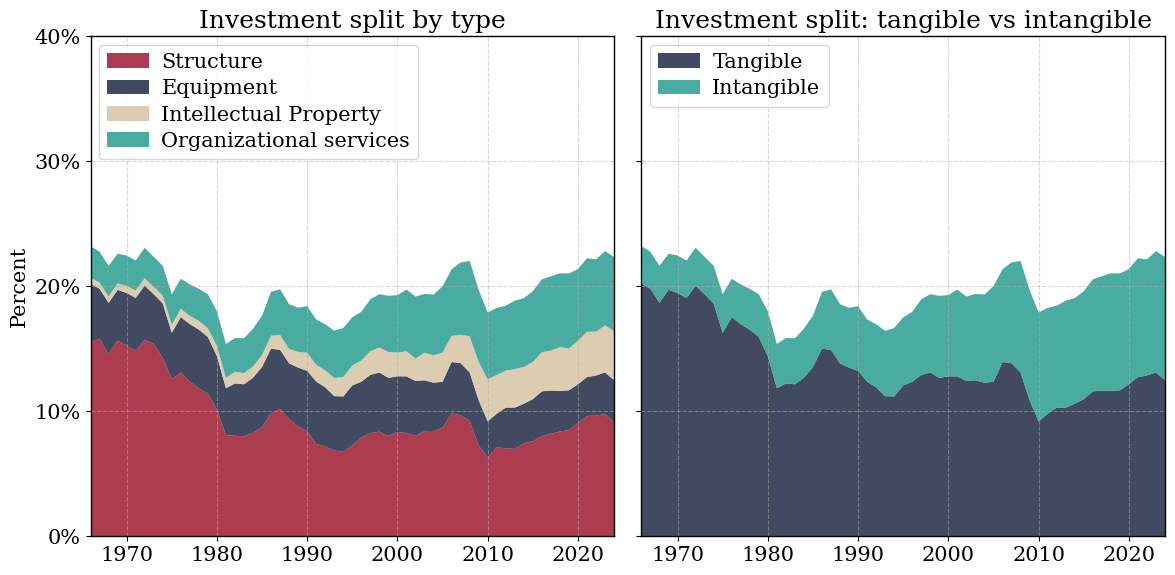

In [430]:
# --- left panel setup (unchanged) ---
order  = ["structures", "equipment", "intellectual_property", "organizational"]
labels = ["Structure", "Equipment", "Intellectual Property", "Organizational services"]

ys_left = np.vstack([wide[c].to_numpy() for c in order])
x       = wide.index.to_numpy()

colors_left = [
    "#9E1B32",  # crimson
    "#1F2A44",  # deep navy
    "#D6C3A5",  # warm sand
    "#2A9D8F",  # teal
]

# --- right panel: tangible vs intangible ---
# Use existing columns if you have them; otherwise compute them from the 4 types
if {"tangible", "intangible"}.issubset(wide.columns):
    tangible   = wide["tangible"].to_numpy()
    intangible = wide["intangible"].to_numpy()
else:
    tangible   = (wide["structures"] + wide["equipment"]).to_numpy()
    intangible = (wide["intellectual_property"] + wide["organizational"]).to_numpy()

ys_right = np.vstack([tangible, intangible])
labels_right = ["Tangible", "Intangible"]
colors_right = [
    "#1F2A44",  # tangible = deep navy
    "#2A9D8F",  # intangible = teal
]

# --- figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# left
polys1 = ax1.stackplot(
    x, ys_left,
    colors=colors_left,
    linewidth=0.8,
    alpha=0.85
)

# right
polys2 = ax2.stackplot(
    x, ys_right,
    colors=colors_right,
    linewidth=0.8,
    alpha=0.85
)

# shared y scale + ticks (same total in both panels)
ymax = float(np.nanmax(ys_left.sum(axis=0)))
ylim_top = ymax * 1.05
for ax in (ax1, ax2):
    ax.set_ylim(0, ylim_top)
    ticks = np.arange(0, max(41, int(np.ceil(ymax / 10) * 10) + 1), 10)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{t:.0f}%" for t in ticks])
    ax.set_xlim(x.min(), x.max())
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

ax1.set_title("Investment split by type")
ax2.set_title("Investment split: tangible vs intangible")
ax1.set_ylabel("Percent")

ax1.legend(handles=polys1, labels=labels, frameon=True, loc="upper left")
ax2.legend(handles=polys2, labels=labels_right, frameon=True, loc="upper left")

plt.tight_layout()
plt.show()

# 2. `Consolidated labour share`

**Data:** 
1. NABP36 for `Compensation of employees` and `GVA`.
2. RAS310 for `educational decomposition`.

*`1. get aggregate labour income share by industry`*

In [431]:
NABP36 = DstApi('RAS310')

# 1. set up relevant inputs
transact = [
    'B1GD',  # B.1g Gross value added
    'D1D',   # D.1 Compensation of employees
]

# 2. set up fetch
params_e = {
    'table': 'NABP36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V']},     # current prices (m. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'BRANCHE', 'values': ['*']},
        {'code': 'TRANSAKT', 'values': transact}
        ]
}

# 3. get and clean
df_e_ = NABP36.get_data(params=params_e)
df_e_['INDHOLD'] = pd.to_numeric(df_e_['INDHOLD'], errors='coerce')

df_e = df_e_.pivot_table(
    index=['TID','BRANCHE'],
    columns='TRANSAKT',
    values='INDHOLD'
).reset_index()

df_e = df_e.rename(columns={
    'B.1g Gross value added'   : 'GVA',
    'D.1 Compensation of employees': 'e_comp'
})

# 4. compute labor share by industry
df_e['labor_share'] = df_e['e_comp'] / df_e['GVA'] * 100

df_e_slim = df_e[['TID','BRANCHE','labor_share','GVA']].copy()

*`2. Educational split by industry`*

In [432]:
RAS310 = DstApi('RAS310')

# 2. set up fetch
params_em = {
    'table': 'RAS310',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['000']}, # all DK
        {'code': 'UDDANNELSE', 'values': ['*']},
        {'code': 'BRANCHE07', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']},
        {'code': 'Tid', 'values': ['*']},
        ]
}

# 3. get and clean
df_em_ = NABP36.get_data(params=params_em)
df_em_['INDHOLD'] = pd.to_numeric(df_em_['INDHOLD'], errors='coerce')

df_em = df_em_.pivot_table(
    index=['TID','BRANCHE07'],
    columns='UDDANNELSE',
    values='INDHOLD'
).reset_index()

# 4. aggregate labour categories
noncollege = ["H10","H20","H30","H35"] 
college    = ["H40","H50","H60","H70","H80"]

df_em = df_em.rename(columns={
    'H10 Primary education'                         : 'H10',
    'H20 Upper secondary education'                 : 'H20',
    'H30 Vocational Education and Training (VET)'   : 'H30',
    'H35 Qualifying educational programs'           : 'H35',
    'H40 Short cycle higher education'              : 'H40',
    'H50 Vocational bachelors educations'           : 'H50',
    'H60 Bachelors programs'                        : 'H60',
    'H70 Masters programs'                          : 'H70',
    'H80 PhD programs'                              : 'H80',
    'H90 Not stated'                                : 'H90',
    'BRANCHE07'                                     : 'BRANCHE',                                 
})

df_em['non_college_s'] = (df_em[noncollege].sum(axis=1) + 0.5*df_em['H90']) / df_em['Total']
df_em['college_s'] = (df_em[college].sum(axis=1) + 0.5*df_em['H90']) / df_em['Total']

# nb. does not exactly sum to one as H90 is not included in either.
# currently just added 50/50 

df_em_slim = df_em[['TID','BRANCHE','non_college_s','college_s']].copy()

*`3. economy wide income split by education`*

In [433]:
INDKP107 = DstApi('INDKP107')
# INDKP107.tablesummary(language='en')
# INDKP107.variable_levels('INDKOMSTTYPE',language='en')

In [434]:
INDKP107 = DstApi('RAS310')

# 1. types of income
inc_type = [
    '115', # Wages and salaries etc., total
    # '120', # Entrepreneurial income, total (not sure how much of this to include if any)
    # '125', #Received fees subject to labour market contr...
]
# 2. set up fetch
params_loen = {
    'table': 'INDKP107',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['000']},          # all DK
        {'code': 'UDDNIV', 'values': ['*']},
        {'code': 'INDKOMSTTYPE', 'values': inc_type},  
        {'code': 'ENHED', 'values': ['121']},           # Average income for people with type of income
        {'code': 'KOEN', 'values': ['MOK']},
        {'code': 'Tid', 'values': ['*']},
        ]
}

# 3. get and clean
df_loen_ = INDKP107.get_data(params=params_loen)
df_loen_['INDHOLD'] = pd.to_numeric(df_loen_['INDHOLD'], errors='coerce')

df_loen = df_loen_.pivot_table(
    index=['TID','INDKOMSTTYPE'],
    columns='UDDNIV',
    values='INDHOLD'
).reset_index()

# 4. aggregate income comp
df_loen = df_loen.rename(columns={
    '10 BASIC SCHOOL 8-10 grade'    : '10',
    '20+25 UPPER SECONDARY SCHOOL': '25',
    '35 VOCATIONAL EDUCATION': '35',
    '40 SHORT-CYCLE HIGHER EDUCATION': '40',
    '50+60 MEDIUM-CYCLE HIGHER EDUCATION, BACHLEOR': '60',
    '65 LONG-CYCLE HIGHER EDUCATION': '65',
})

noncollege_loen = ["10","25","35"]
college_loen    = ["40","60","65"]


df_loen['non_college_wage'] = df_loen[noncollege_loen].sum(axis=1)
df_loen['college_wage'] = df_loen[college_loen].sum(axis=1)

# 5. sum per year
df_loen_year = df_loen.groupby('TID').agg({
    'non_college_wage': 'sum',
    'college_wage': 'sum'
}).reset_index()

*`4. Combine`*, I now have (only data for all sources from 2008.):
1. `df_e`: the labour share per industry, $LS_i$.
2. `df_em`: educational shares by industry, $s_{i,C}$ and $s_{i,N}=1-s_{i,C}$.
3. `df_loen_year`: economy wide wage shifter by education, $\lambda = \omega_C/\omega_N$.

Thus, I find the effective share, i.e the share given the heterogenous wage between groups:
$$
    \tilde s_{i,C} = \frac{s_{i,C} \lambda}{s_{i,C}\lambda + (1-s_{s_{i,C}})}
$$

In [435]:
# 1. collect in one
df = (df_e_slim
      .merge(df_em_slim, on=["TID","BRANCHE"], how="inner")
      .merge(df_loen_year, on="TID", how="inner"))

# 2. wage shifter
df['lambda'] = df['college_wage'] / df['non_college_wage']

# 3. effective labour share
den = df["college_s"] * df["lambda"] + df["non_college_s"] * 1.0
df["wshare_college"] = (df["college_s"] * df["lambda"]) / den
df["wshare_noncol"]  = 1.0 - df["wshare_college"]

df["LS_college"] = df["labor_share"] * df["wshare_college"]
df["LS_noncol"]  = df["labor_share"] * df["wshare_noncol"] 

# 4. clean
df_final = df[["TID","BRANCHE",'labor_share',"LS_college","LS_noncol"]].copy()
df_final['sanity'] = df_final['LS_college'] + df_final['LS_noncol']

*define industry by type, either $C$ og $I$*

In [436]:
# 1. make list of 19 biggest parent classes in terms of consumption share in 2024
top_C = (IO_parent_year.sort_values(by='C_share', ascending=False)
         .head(19)['parent']
         .tolist())

top_I = (IO_parent_year.sort_values(by='intan_share', ascending=False)
         .head(19)['parent']
         .tolist())

print(top_C)
print(top_I)

['SB', 'LB', 'QB', 'QA', 'I', 'O', 'SA', 'P', 'K', 'R', 'JB', 'E', 'CC', 'D', 'JA', 'G', 'CA', 'CD', 'A']
['MC', 'MA', 'MB', 'N', 'JA', 'JC', 'CI', 'P', 'JB', 'CF', 'R', 'K', 'SA', 'QA', 'O', 'QB', 'CD', 'CC', 'B']


In [437]:
# 2. set up mapping
df_final['code'] = df_final['BRANCHE'].str.split(' ').str[0]

# 3. C or I type
IO_parent_year['type'] = np.where(IO_parent_year['parent'].isin(top_C), 'C', 'I')

# 4. map to type
df_final['type'] = df_final['code'].map(IO_parent_year.set_index('parent')['type'])

*plot*

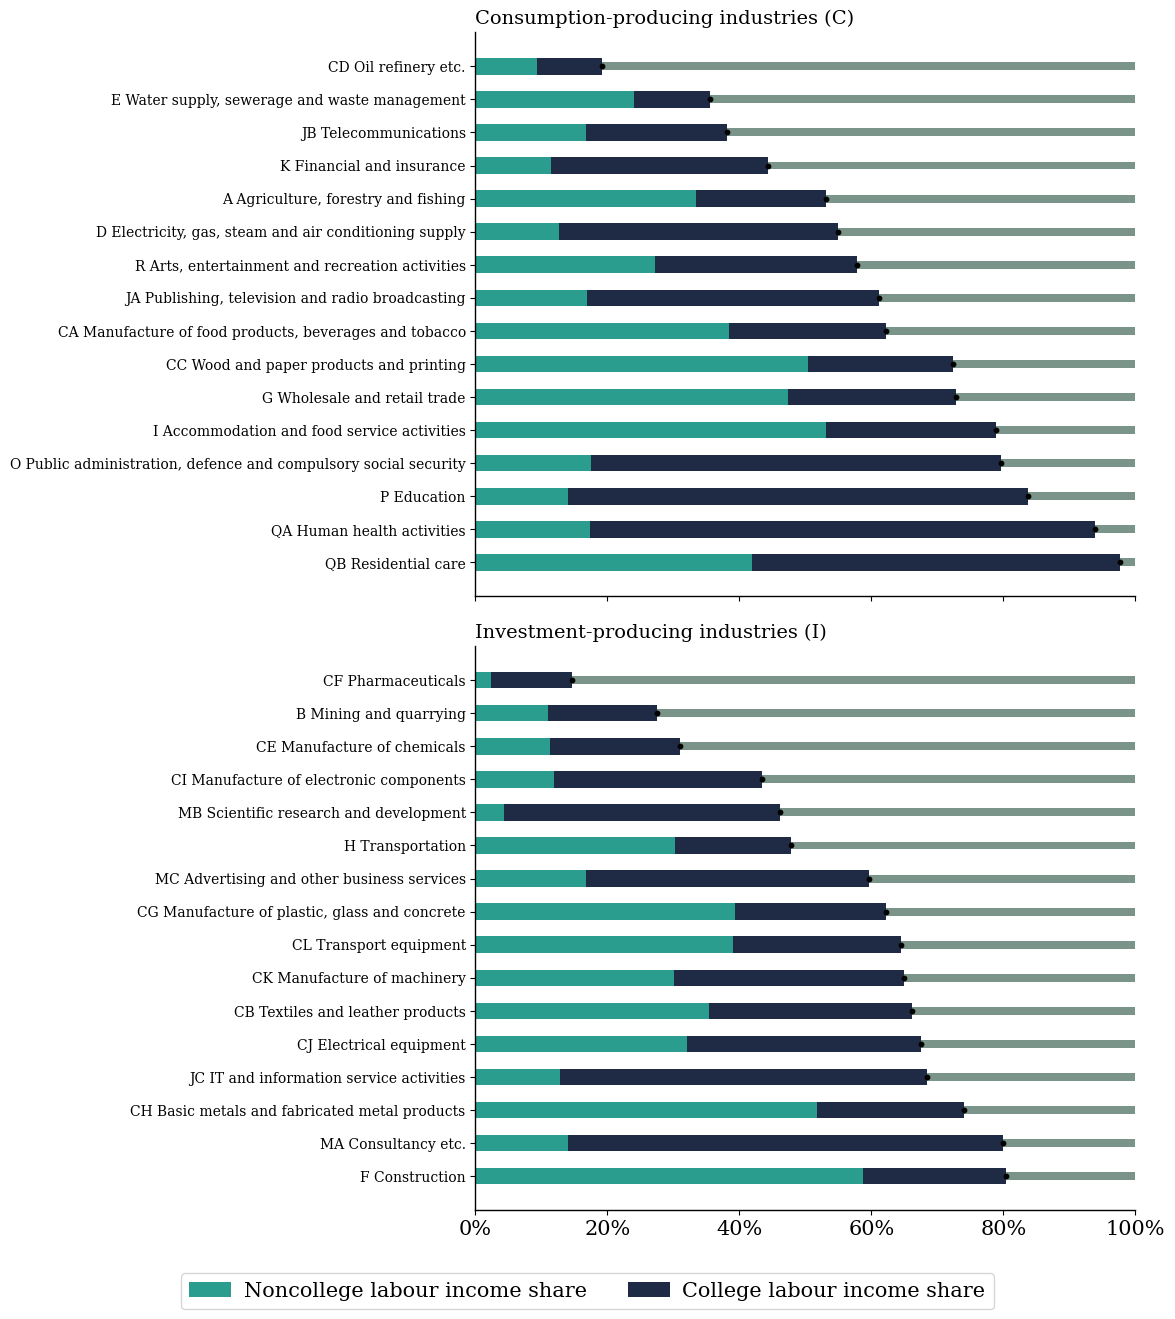

In [438]:
year  = 2024
d = df_final.loc[df_final["TID"] == year].copy()

# split blocks
cons = d.loc[d["type"] == "C"].copy()
inv  = d.loc[d["type"] == "I"].copy()

cons = cons.sort_values("labor_share", ascending=False)
inv  = inv.sort_values("labor_share", ascending=False)

# colours (change if you want)
c_col = "#1F2A44"   # college
c_non = "#2A9D8F"   # noncollege
c_cap = "#7a948a"   # residual to 100

# fig
fig, axes = plt.subplots(2, 1, figsize=(12, 14), sharex=True)

for ax, block, ttl in [
    (axes[0], cons, "Consumption-producing industries (C)"),
    (axes[1], inv,  "Investment-producing industries (I)"),
]:
    y = np.arange(len(block))

    noncol = block["LS_noncol"].to_numpy()
    col    = block["LS_college"].to_numpy()
    lab    = block["labor_share"].to_numpy()
    cap    = 100.0 - lab
    
    # stacked bars: noncollege + college + residual (capital share)
    ax.barh(y, noncol, color=c_non, 
            edgecolor="none", height=0.5, 
            label="Noncollege labour income share")
    
    ax.barh(y, col, left=noncol, color=c_col, 
            edgecolor="none", height=0.5, 
            label="College labour income share")
    
    ax.barh(y, cap, left=lab, color=c_cap, edgecolor="none", height=0.24)

    # dot at total labour share
    ax.scatter(lab, y, s=10, color="k", zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(block["BRANCHE"], fontsize=10)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_xticklabels([f"{v:d}%" for v in range(0, 101, 20)])

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(ttl, loc="left", fontsize=14)

# one legend for the whole figure (only the two labour components)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles[:2], labels[:2], loc="lower center", 
    ncol=2, frameon=True, bbox_to_anchor=(0.5, 0.02))

# fig.suptitle(f"Labour share split by education, {year}", y=0.995)
plt.tight_layout(rect=(0, 0.06, 1, 0.97))
plt.show()

*`5. economy wide labour income share by labourer type`* These I compute, given weights dependent on the industry to obtain weighted averages
$$
    w_i^C = \frac{C_i}{\sum_j C_j}, \quad w^I_i = \frac{I_i}{\sum_j I_j},
$$ 
then the aggregate labour shares are:
$$
    LS^C = \sum_i w_i^C LS_i, \quad L_S^I = \sum_i w_i^I LS_i.
$$

I use the labour share by type stored in `df_final` and the weights can be computed from `IO_parent`

In [439]:
# 1. compute aggregate consumption / investment
IO_parent["agg_C"] = IO_parent["C"] + IO_parent["G"]
IO_parent["agg_I"] = IO_parent["intan"] + IO_parent["tan"]
IO_w_ = IO_parent[["TID","parent","agg_C","agg_I"]].copy()

# 2. merge with labour shares
IO_w_ = IO_w_.merge(
    df_final[["TID","code","labor_share","LS_college","LS_noncol"]],
    left_on=["TID","parent"],
    right_on=["TID","code"],
    how="left"
)

# 3. drop nan rows after merge
IO_w = IO_w_.dropna(subset=["labor_share","LS_college","LS_noncol"]).copy()

print("parents kept:", IO_w["parent"].nunique())
print("parents total:", IO_w_["parent"].nunique())

# 4. weights (by year)
IO_w["C_w"] = IO_w["agg_C"] / IO_w.groupby("TID")["agg_C"].transform("sum")
IO_w["I_w"] = IO_w["agg_I"] / IO_w.groupby("TID")["agg_I"].transform("sum")

# 5. weighted labour shares per year (aggregate + by education)
d = IO_w.copy()

agg = (d.groupby("TID")
       .apply(lambda g: pd.Series({
           # totals (paper eq 2.1)
           "LS_C": np.sum(g["C_w"] * g["labor_share"]),
           "LS_I": np.sum(g["I_w"] * g["labor_share"]),

           # by labour type (these should add up to LS_C / LS_I)
           "LS_C_college": np.sum(g["C_w"] * g["LS_college"]),
           "LS_C_noncol":  np.sum(g["C_w"] * g["LS_noncol"]),
           "LS_I_college": np.sum(g["I_w"] * g["LS_college"]),
           "LS_I_noncol":  np.sum(g["I_w"] * g["LS_noncol"]),

           # totals for reference
           "C_tot": g["agg_C"].sum(),
           "I_tot": g["agg_I"].sum(),
       }))
       .reset_index()
)

parents kept: 32
parents total: 38


/var/folders/t6/3c29w60n57n_vr9ftbb88pdr0000gn/T/ipykernel_4289/217991385.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


*plot*

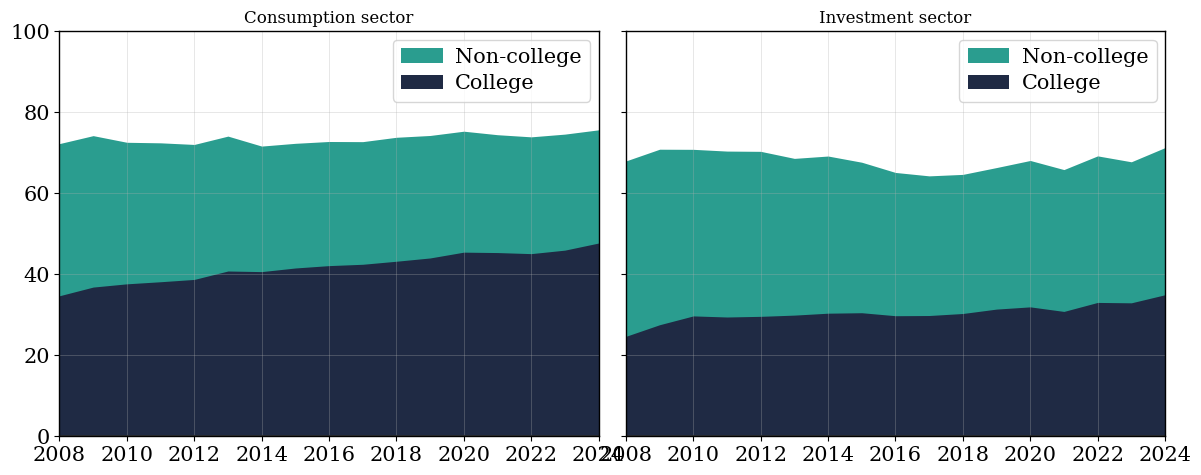

In [443]:
x = agg["TID"].to_numpy()

C_col = agg["LS_C_college"].to_numpy()
C_non = agg["LS_C_noncol"].to_numpy()
I_col = agg["LS_I_college"].to_numpy()
I_non = agg["LS_I_noncol"].to_numpy()

# if your series are in [0,1], uncomment:
# C_col, C_non, I_col, I_non = [s*100 for s in (C_col, C_non, I_col, I_non)]

# --- your vibe: crisp, minimal, crimson accent + neutral fills
crimson = "#B11226"
slate   = "#2E3440"
fog     = "#E7E9EE"
steel   = "#C9D2DF"

c_col = "#1F2A44"   # college
c_non = "#2A9D8F"   # noncollege


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

def pct(x, pos):  # y-axis formatter
    return f"{x:.0f}%"

ymax = np.nanmax([C_col + C_non, I_col + I_non])
ymax = float(np.ceil(max(ymax, 60) / 10) * 10)  # round up to nearest 10
ymax = min(max(ymax, 70), 100)                  # keep sane

for ax, col, non, panel_title in [
    (axes[0], C_col, C_non, "Consumption sector"),
    (axes[1], I_col, I_non, "Investment sector"),
]:
    top = col + non

    # background "total labor share" fill (neutral)
    ax.fill_between(x, 0, top, color=c_non, linewidth=0, label="Non-college")

    # college fill (crimson accent)
    ax.fill_between(x, 0, col, color=c_col, linewidth=0, label='College')

    # subtle baseline
    ax.axhline(0, color="0.2", linewidth=1.2)

    ax.set_title(panel_title, fontsize=12)
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, 100)
    
    # clean spines + ticks

    # minimalist grid (very faint)
    ax.grid(linewidth=0.6, alpha=0.35)

    # in-panel labels (low-key)
    ax.legend()

# single figure title (also your style: understated)
plt.tight_layout()
plt.show()
